In [138]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input',
                                'spruce_root_ingrowth_2014_2017_20200408.csv'), 
                   encoding='latin-1')

# skip the units column
data = data.loc[1:, :]
data['plot'] = data['plot'].astype(int)
data = data.loc[data['pft'] != 'graminoid']
data.set_index(['season', 'plot', 'topog', 'pft', 'root_order'], inplace = True)

# calculate the length of season
ndays = (pd.DatetimeIndex(data['end_date']) - pd.DatetimeIndex(data['start_date'])).days

data = data.loc[:, 'root_biomass'].astype(float) / 365 # g/m2/season => g/m2/day

data = data.unstack()

# convert to total biomass of all fine root orders
data['total'] = data['1to3'] + data['4+']
data['filled'] = np.where(data['all_orders'].isna(), data['total'], data['all_orders'])

data = data['filled'].unstack()

# add winter measurements to year 2016
# (double checked the indices are aligned and result okay)
data.loc['summer_2016', :] = (data.loc['summer_2016'] + data.loc['winter_15_16']).values
data = data.drop('winter_15_16', level = 0, axis = 0)

# g/m2/day
data = data.reset_index()
data['year'] = [int(x.split('_')[1]) for x in data['season']]
data = data.drop('season', axis = 1)
root_growth = data.set_index(['topog','year','plot']).sort_index()

In [139]:
root_growth_2014 = root_growth.loc[('hollow', 2014), :] * 0.36 + \
                   root_growth.loc[('hummock', 2014), :] * 0.64
root_growth_2014_mean = root_growth_2014.mean()
root_growth_2014_std = root_growth_2014.std()

Total uncertainty by squared-sum combination =  61.72226466959154


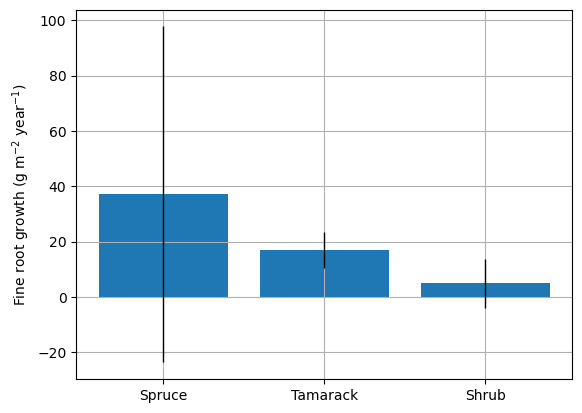

In [157]:
fig, ax = plt.subplots()
ax.bar(x = range(3), height = root_growth_2014_mean*365)
ax.errorbar(x = range(3), y = root_growth_2014_mean*365, 
            yerr = root_growth_2014_std*365, color = 'k', lw = 0, 
            elinewidth = 1)
ax.set_ylabel('Fine root growth (g m$^{-2}$ year$^{-1}$)')
ax.set_xticks(range(3))
ax.set_xticklabels(['Spruce','Tamarack','Shrub'])
ax.grid(True)

print('Total uncertainty by squared-sum combination = ',
      np.sqrt(np.sum(np.power(root_growth_2014_std*365, 2))))

In [104]:
plot_list = list(root_growth.index.levels[1])
data_all = {}
for plot in plot_list:
    data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                             'WEW_Complete_Environ_20220518', 
                             f'WEW PLOT_{plot:02d}_Complete_Environ_20220518.csv'))
    # 2m air temperature
    data['TA_2_0'] = data[['TA_2_0__1','TA_2_0__2']].mean(axis = 1)
    data = data[['TIMESTAMP', 'Plot', 'TA_2_0']].dropna(how = 'any')
    data['TIMESTAMP'] = pd.DatetimeIndex(data['TIMESTAMP'])
    data = data.drop_duplicates(subset=['TIMESTAMP'])
    data = data.set_index('TIMESTAMP')['TA_2_0']
    data = data.reindex(pd.date_range(data.index[0], data.index[-1], freq = '0.5H'))
    data = data.interpolate(method = 'linear', limit = 24)
    data_all[plot] = data
data_all = pd.DataFrame(data_all)
tair = data_all.resample('1Y').mean()
tair.index = tair.index.year

/tmp/ipykernel_3975306/2368282033.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input',
/tmp/ipykernel_3975306/2368282033.py:4: DtypeWarning: Columns (99) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input',
